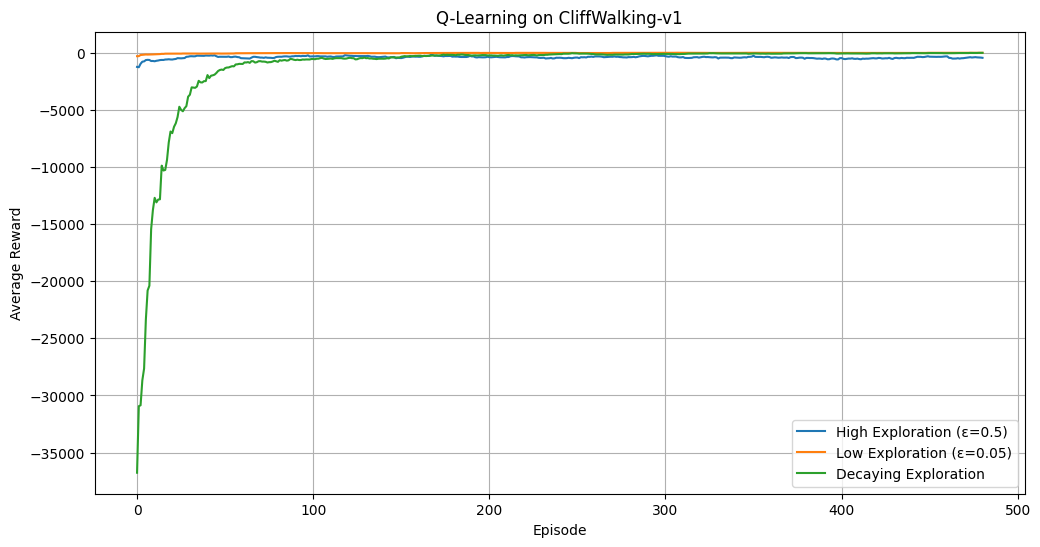

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Create environment
env = gym.make("CliffWalking-v1")

# Q-learning parameters
alpha = 0.1          # learning rate
gamma = 0.99         # discount factor
episodes = 500

n_states = env.observation_space.n
n_actions = env.action_space.n


def q_learning(strategy="high"):

    # Initialize Q-table
    Q = np.zeros((n_states, n_actions))

    rewards_per_episode = []

    for episode in range(episodes):

        state, _ = env.reset()
        done = False

        total_reward = 0

        # Exploration strategies
        if strategy == "high":
            epsilon = 0.5

        elif strategy == "low":
            epsilon = 0.05

        elif strategy == "decay":
            # Exponential decay
            epsilon = max(0.01, 1.0 * (0.995 ** episode))

        while not done:

            # Epsilon-greedy action selection
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated

            # Q-learning update
            best_next_action = np.argmax(Q[next_state])

            Q[state, action] = Q[state, action] + alpha * (
                reward
                + gamma * Q[next_state, best_next_action]
                - Q[state, action]
            )

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode


# Train all agents
Q_high, rewards_high = q_learning("high")
Q_low, rewards_low = q_learning("low")
Q_decay, rewards_decay = q_learning("decay")


# Moving average for smoother plots
def moving_average(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')


# Plot results
plt.figure(figsize=(12,6))

plt.plot(moving_average(rewards_high), label="High Exploration (ε=0.5)")
plt.plot(moving_average(rewards_low), label="Low Exploration (ε=0.05)")
plt.plot(moving_average(rewards_decay), label="Decaying Exploration")

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning on CliffWalking-v1")
plt.legend()
plt.grid()

plt.show()